# Residue Cluster Filter

After arm mask subtraction the subtracted depth images still contain small residue fragments (arm bleed-through).
This notebook clusters non-zero pixels by a **KNN graph** (each pixel connected to its k spatial nearest neighbours),
then keeps only the **largest connected component** — which should be the object (teddy bear).

Pipeline per image:
1. Load 16-bit subtracted depth PNG.
2. Extract `(y, x)` coordinates of all non-zero pixels.
3. Build a KNN graph with `sklearn.neighbors.NearestNeighbors`.
4. Find connected components on the KNN graph with `scipy.sparse.csgraph`.
5. Keep only pixels belonging to the largest component; zero out everything else.
6. Save the cleaned depth PNG and a comparison visualisation.

## Settings

In [1]:
import os

# ── Paths ─────────────────────────────────────────────────────────────────────
SESSION_ROOT   = "/home/bozznyskrtt/pcl_ws/teddybear/session17"
INPUT_DIR      = os.path.join(SESSION_ROOT, "test_outputs_mask_depth_refined_640x480", "subtracted_depth_raw")
GT_MASK_DIR    = os.path.join(SESSION_ROOT, "test_outputs_mask_depth_refined_640x480", "gt_masks")
OUTPUT_DIR     = os.path.join(SESSION_ROOT, "test_outputs_knn_filtered")

# ── KNN clustering params ─────────────────────────────────────────────────────
K_NEIGHBORS    = 5    # each pixel is connected to its K nearest neighbours
MAX_DIST_PX    = 4.0  # maximum pixel distance to create an edge (prunes far-away links)

# ── Visualisation ─────────────────────────────────────────────────────────────
SAVE_COMPARISONS = True  # save side-by-side comparison images

#1

## Imports

In [2]:
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
import scipy.sparse.csgraph as csgraph

/home/bozznyskrtt/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Core: KNN-graph cluster filter

In [3]:
def knn_keep_largest(depth_u16: np.ndarray,
                     k: int = 5,
                     max_dist_px: float = 4.0
                     ) -> tuple[np.ndarray, dict]:
    """
    Remove residue blobs from a 16-bit subtracted depth image.

    Parameters
    ----------
    depth_u16   : (H, W) uint16 array — subtracted depth (0 = no depth)
    k           : number of nearest neighbours per pixel
    max_dist_px : maximum edge distance in pixels; longer edges are ignored

    Returns
    -------
    cleaned     : (H, W) uint16 — only the largest cluster survives
    info        : dict with cluster statistics
    """
    # ── 1. Find non-zero pixel positions ──────────────────────────────────────
    ys, xs = np.where(depth_u16 > 0)
    if len(ys) == 0:
        return depth_u16.copy(), {"n_clusters": 0, "sizes": [], "kept_size": 0}

    coords = np.column_stack([ys, xs]).astype(np.float32)  # (N, 2)

    # ── 2. Build KNN graph ────────────────────────────────────────────────────
    k_actual = min(k, len(coords))            # can't ask for more neighbours than points
    nn = NearestNeighbors(n_neighbors=k_actual, algorithm="kd_tree", metric="euclidean")
    nn.fit(coords)
    distances, indices = nn.kneighbors(coords)

    # Build sparse adjacency matrix; ignore edges longer than max_dist_px
    N = len(coords)
    rows, cols, data = [], [], []
    for i in range(N):
        for j_idx in range(1, k_actual):          # skip self (index 0)
            j   = indices[i, j_idx]
            d   = distances[i, j_idx]
            if d <= max_dist_px:
                rows.append(i); cols.append(j); data.append(1.0)
                rows.append(j); cols.append(i); data.append(1.0)

    adj = sp.csr_matrix((data, (rows, cols)), shape=(N, N))

    # ── 3. Connected components on the KNN graph ──────────────────────────────
    n_components, labels = csgraph.connected_components(adj, directed=False)

    # ── 4. Find largest component ─────────────────────────────────────────────
    component_sizes = np.bincount(labels)        # size of each component
    largest_label   = int(np.argmax(component_sizes))

    # ── 5. Build output image ─────────────────────────────────────────────────
    cleaned = np.zeros_like(depth_u16)
    keep_mask = labels == largest_label          # boolean mask over non-zero pixels
    cleaned[ys[keep_mask], xs[keep_mask]] = depth_u16[ys[keep_mask], xs[keep_mask]]

    info = {
        "n_clusters": n_components,
        "sizes"     : sorted(component_sizes.tolist(), reverse=True)[:10],
        "kept_size" : int(component_sizes[largest_label]),
    }
    return cleaned, info

## Main loop

In [4]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
cleaned_dir    = os.path.join(OUTPUT_DIR, "cleaned_depth")
compare_dir    = os.path.join(OUTPUT_DIR, "comparisons")
os.makedirs(cleaned_dir, exist_ok=True)
if SAVE_COMPARISONS:
    os.makedirs(compare_dir, exist_ok=True)

input_files = sorted(glob.glob(os.path.join(INPUT_DIR, "depth_*.png")))
print(f"Found {len(input_files)} subtracted depth images in {INPUT_DIR}")

Found 119 subtracted depth images in /home/bozznyskrtt/pcl_ws/teddybear/session17/test_outputs_mask_depth_refined_640x480/subtracted_depth_raw


In [5]:
import csv

stats_rows = []

for fpath in input_files:
    fname = os.path.basename(fpath)                                # e.g. depth_0000.png

    # ── load subtracted depth ────────────────────────────────────────────────
    depth_raw  = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)          # uint16
    if depth_raw is None:
        print(f"  [WARN] could not read {fpath}")
        continue

    # ── cluster & keep largest ───────────────────────────────────────────────
    cleaned, info = knn_keep_largest(depth_raw, k=K_NEIGHBORS, max_dist_px=MAX_DIST_PX)

    # ── save cleaned depth ───────────────────────────────────────────────────
    out_name  = fname
    out_path  = os.path.join(cleaned_dir, out_name)
    cv2.imwrite(out_path, cleaned)

    # ── statistics row ───────────────────────────────────────────────────────
    stats_rows.append({
        "stem"        : fname,
        "n_clusters"  : info["n_clusters"],
        "kept_px"     : info["kept_size"],
        "total_px"    : int(np.count_nonzero(depth_raw)),
        "removed_px"  : int(np.count_nonzero(depth_raw)) - info["kept_size"],
        "top10_sizes" : str(info["sizes"]),
    })

    # ── optional comparison visualisation ───────────────────────────────────
    if SAVE_COMPARISONS:
        # try to load matching GT mask for context
        gt_mask_path = os.path.join(GT_MASK_DIR, fname)
        gt_mask = cv2.imread(gt_mask_path, cv2.IMREAD_GRAYSCALE) if os.path.exists(gt_mask_path) else None

        # normalise for display (map 16-bit → 0-255)
        def norm16(img):
            v = img.astype(np.float32)
            mx = v.max()
            if mx == 0:
                return np.zeros_like(img, dtype=np.uint8)
            return (v / mx * 255).astype(np.uint8)

        n_cols = 4 if gt_mask is not None else 3
        fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 3, 3))

        axes[0].imshow(norm16(depth_raw), cmap="gray")
        axes[0].set_title("Subtracted (input)")
        axes[0].axis("off")

        axes[1].imshow(norm16(cleaned), cmap="gray")
        axes[1].set_title(f"Cleaned\n(kept {info['kept_size']} px)")
        axes[1].axis("off")

        # residue = pixels that were removed
        residue = depth_raw.copy()
        residue[cleaned > 0] = 0
        axes[2].imshow(norm16(residue), cmap="hot")
        axes[2].set_title(f"Removed residue\n({info['n_clusters']-1} blobs)")
        axes[2].axis("off")

        if gt_mask is not None:
            axes[3].imshow(gt_mask, cmap="gray")
            axes[3].set_title("GT mask")
            axes[3].axis("off")

        plt.suptitle(fname, fontsize=9)
        plt.tight_layout()
        fig.savefig(os.path.join(compare_dir, fname), dpi=120, bbox_inches="tight")
        plt.close(fig)

print(f"Done. Saved {len(stats_rows)} cleaned images to {cleaned_dir}")

Done. Saved 119 cleaned images to /home/bozznyskrtt/pcl_ws/teddybear/session17/test_outputs_knn_filtered/cleaned_depth


## Save statistics CSV

In [6]:
csv_path = os.path.join(OUTPUT_DIR, "knn_filter_stats.csv")
if stats_rows:
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=stats_rows[0].keys())
        writer.writeheader()
        writer.writerows(stats_rows)
    print(f"Stats saved to {csv_path}")

# summary
removed = [r["removed_px"] for r in stats_rows]
total   = [r["total_px"]   for r in stats_rows]
print(f"\nSummary over {len(stats_rows)} images:")
print(f"  avg non-zero before : {np.mean(total):.0f} px")
print(f"  avg removed residue : {np.mean(removed):.0f} px  ({100*np.mean(removed)/np.mean(total):.1f}%)")
print(f"  avg kept            : {np.mean([r['kept_px'] for r in stats_rows]):.0f} px")

Stats saved to /home/bozznyskrtt/pcl_ws/teddybear/session17/test_outputs_knn_filtered/knn_filter_stats.csv

Summary over 119 images:
  avg non-zero before : 38776 px
  avg removed residue : 4018 px  (10.4%)
  avg kept            : 34758 px


## Spot-check: view a few examples

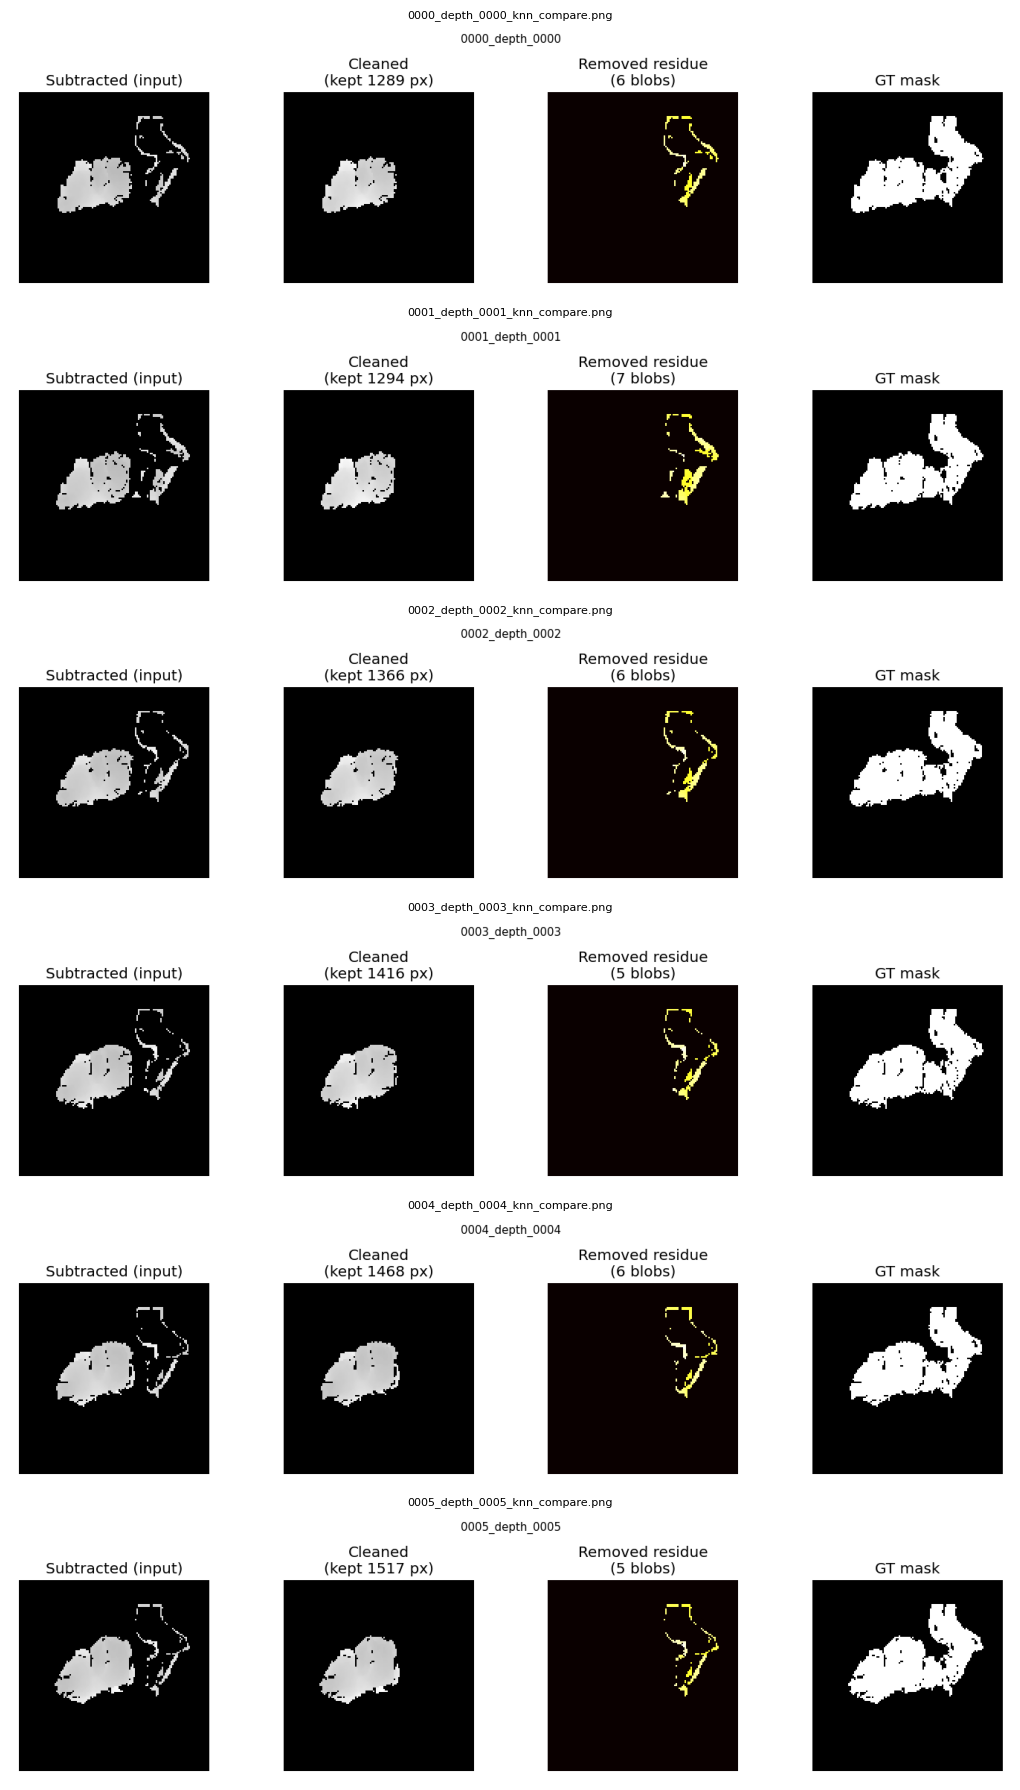

In [7]:
# Shows the first 6 comparison images inline
sample_files = sorted(glob.glob(os.path.join(compare_dir, "*_knn_compare.png")))[:6]

fig, axes = plt.subplots(len(sample_files), 1, figsize=(14, len(sample_files) * 3))
if len(sample_files) == 1:
    axes = [axes]
for ax, fp in zip(axes, sample_files):
    img = cv2.imread(fp)[..., ::-1]   # BGR→RGB
    ax.imshow(img)
    ax.set_title(os.path.basename(fp), fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Tuning notes

| Parameter | Effect |
|---|---|
| `K_NEIGHBORS` | More neighbours → harder to split touching blobs. Start at 5. |
| `MAX_DIST_PX` | Larger gap tolerance → merges blobs that are close but not touching. Try 2–8 px. |

If the object and arm residue are **touching**, KNN-graph clustering won't separate them — use a smaller `MAX_DIST_PX` or fall back to area threshold (drop components smaller than N pixels).